In [2]:
import dcsp_module as d
from metadata_module import read_metadata


In [3]:
import config as c

In [4]:
m = read_metadata()

In [5]:
m

,site,patient_id,exam_id,age,age_group,female,pathology
0,S00,P32423,20220512-151756-{195a4196-0111-4fa5-a0a2-951e8...,47.0,46-55,1,1
1,S00,P28507,20220512-163015-{f7af3b95-1afd-4de4-8b7e-78c46...,46.9,46-55,1,0
2,S00,P28506,20220512-162932-{408352a4-978b-4b42-bff2-62db7...,40.6,36-45,0,1
3,S00,P28505,20220512-162946-{3ad3c86b-3d61-440e-81df-b74fd...,36.9,36-45,0,1
4,S00,P28504,20220512-163006-{6e353308-dcd5-4cdd-9ae3-c3fa8...,52.6,46-55,0,1
...,...,...,...,...,...,...,...
51130,S29,P32549,20220602-152610-{7008a1d7-3ce6-4a20-9b1c-3df5a...,16.2,16-25,0,0
51131,S29,P32548,20220602-152655-{f7a40810-55c6-4f15-a461-76758...,62.7,56-65,0,1
51132,S29,P32547,20220602-152850-{7f63b022-3c53-4b2c-80ff-69e79...,40.2,36-45,0,0
51133,S29,P29278,20220602-152230-{f52ece77-e74b-493c-9524-beec6...,17.5,16-25,0,0


In [6]:
id = 408
row = m.iloc[id]

In [7]:
row["pathology"]

np.int64(0)

In [8]:
row = m.iloc[id]
eeg, info = d.load_and_process_continuous_eeg(row)
print(info)
if eeg is None:
    print("Not processed")
else:
    print("Pathology?", row["pathology"])
    print(eeg.raw.ch_names == c.VALID_CHANNELS_AFTER_DROP)
    print(eeg.raw.info["sfreq"]) #expected c.DEFAULT_SFREQ
    print(eeg.raw.get_data().std()) # ~1e-5 to 1e-4 volts expected

Extracting EDF parameters from /dmj/fizmed/mmarzec/licencjat_neuro/baza_elm19/ELM19_edfs/20220512-164526-{868d3666-ce31-4c89-8dfd-d5377281e93c}.edf...
Channel 'EEG Fp1' recognized as type EEG (renamed to 'Fp1').
Channel 'EEG Fp2' recognized as type EEG (renamed to 'Fp2').
Channel 'EEG F7' recognized as type EEG (renamed to 'F7').
Channel 'EEG F3' recognized as type EEG (renamed to 'F3').
Channel 'EEG Fz' recognized as type EEG (renamed to 'Fz').
Channel 'EEG F4' recognized as type EEG (renamed to 'F4').
Channel 'EEG F8' recognized as type EEG (renamed to 'F8').
Channel 'EEG T3' recognized as type EEG (renamed to 'T3').
Channel 'EEG C3' recognized as type EEG (renamed to 'C3').
Channel 'EEG Cz' recognized as type EEG (renamed to 'Cz').
Channel 'EEG C4' recognized as type EEG (renamed to 'C4').
Channel 'EEG T4' recognized as type EEG (renamed to 'T4').
Channel 'EEG T5' recognized as type EEG (renamed to 'T5').
Channel 'EEG P3' recognized as type EEG (renamed to 'P3').
Channel 'EEG Pz' re

Using matplotlib as 2D backend.


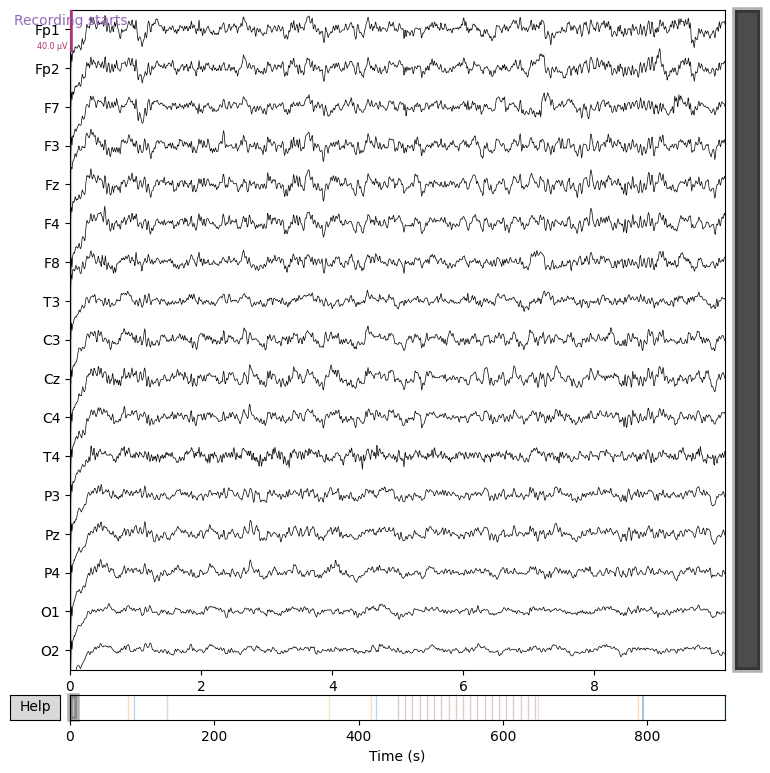

In [9]:
g = eeg.raw.plot()

In [10]:
info

{'site': 'S00',
 'exam_id': '20220512-164526-{868d3666-ce31-4c89-8dfd-d5377281e93c}',
 'initial_fs': 250.0,
 'n_all_windows': 151,
 'ch_non_eeg': '["ECG", "RESP1", "RESP2"]',
 'status': 'ok',
 'ch_drop': '["S8", "S9", "S1", "S2"]'}